# Inferencia — Imagen individual proporcionada por el usuario

Carga el mejor modelo entrenado y clasifica **una sola imagen** que el usuario sube directamente desde su equipo.

# **Instrucciones**

Ejecuta todo el código haciendo lo siguiente:



1.   En el menú superior de la ventada, dar clic en "Entorno de Ejecución"
2.   Clic en ejecutar todas
3.   Desplázate hacia abjo del código, en la celda 6 te aparecerá un boton de "Examinar"
4. Da clic en "Examinar"
5. Busca tu archivo de imagen
6. Al final del cuaderno verás el resultado



## 1. Librerías

In [1]:
import os
import io

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image
from torchvision.transforms import (
    Compose, Normalize, Resize, CenterCrop, ToTensor
)
from google.colab import files

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Configuración

In [3]:
#BEST_MODEL_PATH = "https://drive.google.com/file/d/1WcitVqvZ6cG-mONSgnPQYunfh58PiUrQ/view?usp=sharing"

!gdown --id 1WcitVqvZ6cG-mONSgnPQYunfh58PiUrQ

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WcitVqvZ6cG-mONSgnPQYunfh58PiUrQ
From (redirected): https://drive.google.com/uc?id=1WcitVqvZ6cG-mONSgnPQYunfh58PiUrQ&confirm=t&uuid=7567035d-3ec4-4475-a093-e16e66103294
To: /content/best_model_finetuning.pt
100% 350M/350M [00:04<00:00, 72.1MB/s]


In [4]:
# ── Ruta al mejor modelo guardado ─────────────────────────────────────────────
BEST_MODEL_PATH = '/content/best_model_finetuning.pt'

# ── Clases (mismo orden que ImageFolder durante el entrenamiento) ──────────────
CLASS_NAMES = [
    'Aroma22', 'CLL18', 'Clusters', 'FM', 'JazTec',
    'RT7221FP', 'RT7301', 'RT7521FP', 'RTv7303',
    'Taurus', 'XP760MA', 'XP784'
]
NUM_CLASSES = len(CLASS_NAMES)

# ── Top-K predicciones a mostrar ──────────────────────────────────────────────
TOP_K = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo : {device}")
print(f"Clases      : {CLASS_NAMES}")

Dispositivo : cuda
Clases      : ['Aroma22', 'CLL18', 'Clusters', 'FM', 'JazTec', 'RT7221FP', 'RT7301', 'RT7521FP', 'RTv7303', 'Taurus', 'XP760MA', 'XP784']


## 4. Cargar el modelo

In [5]:
def build_convnext(num_classes: int):
    """Misma arquitectura usada durante el entrenamiento."""
    model = models.convnext_base(weights=None)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model


model = build_convnext(NUM_CLASSES)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Modelo cargado y listo.")

Modelo cargado y listo.


## 5. Transform de evaluación

In [6]:
eval_tfms = Compose([
    Resize(256),
    CenterCrop(224),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406],
              std =[0.229, 0.224, 0.225]),
])

print("Transform de evaluación definido.")

Transform de evaluación definido.


# 6. Subir imagen

Ejecuta la celda y selecciona **una imagen** desde tu equipo (`.jpg`, `.jpeg` o `.png`).

In [7]:
uploaded = files.upload()   # abre el selector de archivos de Colab

if not uploaded:
    raise RuntimeError("No se subió ningún archivo.")

filename  = list(uploaded.keys())[0]
img_bytes = uploaded[filename]
image_pil = Image.open(io.BytesIO(img_bytes)).convert("RGB")

print(f"Imagen cargada : {filename}")
print(f"Tamaño original: {image_pil.size[0]} × {image_pil.size[1]} px")

Saving 20250303164157_000005.jpg to 20250303164157_000005.jpg
Imagen cargada : 20250303164157_000005.jpg
Tamaño original: 100 × 100 px


# 7. Inferencia

In [8]:
tensor = eval_tfms(image_pil).unsqueeze(0).to(device)   # [1, 3, 224, 224]

with torch.no_grad():
    logits = model(tensor)                               # [1, num_classes]
    probs  = torch.softmax(logits, dim=1).squeeze()      # [num_classes]

# Top-K
topk_probs, topk_ids = probs.topk(TOP_K)
topk_probs = topk_probs.cpu().numpy()
topk_ids   = topk_ids.cpu().numpy()

pred_class = CLASS_NAMES[topk_ids[0]]
pred_conf  = topk_probs[0]

print(f"\n{'='*40}")
print(f"  Predicción : {pred_class}")
print(f"  Confianza  : {pred_conf*100:.2f}%")
print(f"{'='*40}")
print(f"\nTop-{TOP_K} predicciones:")
for rank, (cid, prob) in enumerate(zip(topk_ids, topk_probs), 1):
    bar = '█' * int(prob * 30)
    print(f"  {rank}. {CLASS_NAMES[cid]:<14} {prob*100:6.2f}%  {bar}")


  Predicción : RT7521FP
  Confianza  : 91.11%

Top-5 predicciones:
  1. RT7521FP        91.11%  ███████████████████████████
  2. RTv7303          0.82%  
  3. Aroma22          0.81%  
  4. Taurus           0.81%  
  5. JazTec           0.81%  


# 8. Visualización

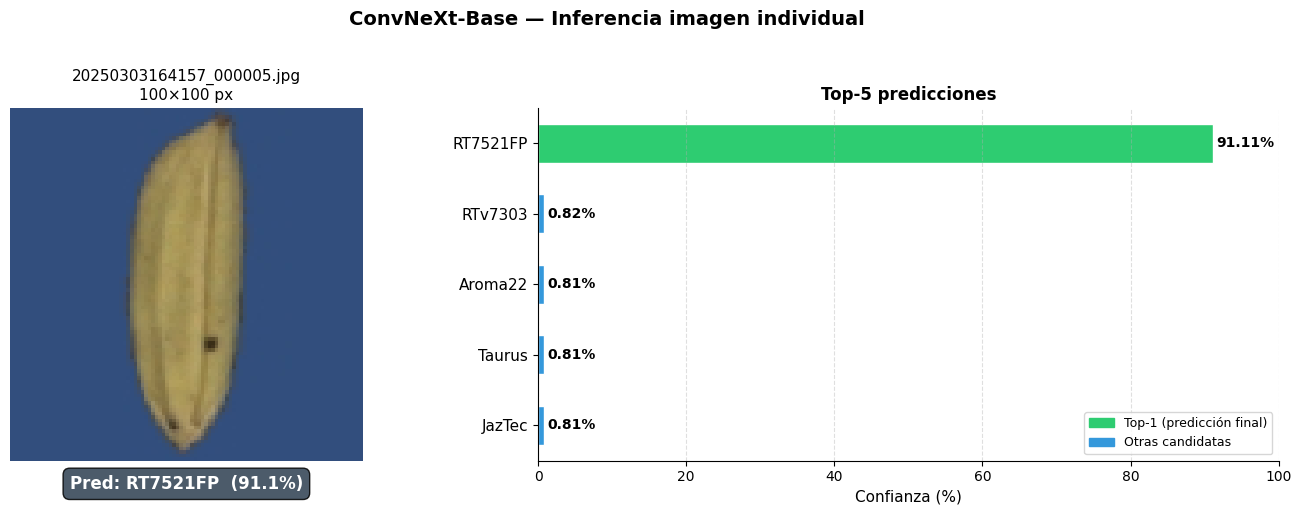

Figura guardada como inference_20250303164157_000005.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"width_ratios": [1, 1.4]})

# ── Panel izquierdo: imagen original ─────────────────────────────────────────
axes[0].imshow(image_pil)
axes[0].axis("off")
axes[0].set_title(
    f"{filename}\n{image_pil.size[0]}×{image_pil.size[1]} px",
    fontsize=11
)

# Recuadro con la predicción principal
axes[0].text(
    0.5, -0.04,
    f"Pred: {pred_class}  ({pred_conf*100:.1f}%)",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=12, fontweight="bold",
    color="white",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#2c3e50", alpha=0.85)
)

# ── Panel derecho: barras Top-K ───────────────────────────────────────────────
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(TOP_K)]
labels = [CLASS_NAMES[cid] for cid in topk_ids]
values = topk_probs * 100

bars = axes[1].barh(range(TOP_K), values, color=colors, edgecolor="white",
                    height=0.55)

# Etiquetas de valor dentro de cada barra
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}%",
        va="center", ha="left", fontsize=10, fontweight="bold"
    )

axes[1].set_yticks(range(TOP_K))
axes[1].set_yticklabels(labels, fontsize=11)
axes[1].invert_yaxis()   # la clase con mayor prob arriba
axes[1].set_xlabel("Confianza (%)", fontsize=11)
axes[1].set_title(f"Top-{TOP_K} predicciones", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, min(values[0] * 1.25, 100))
axes[1].grid(axis="x", linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)

# Leyenda
top1_patch = mpatches.Patch(color="#2ecc71", label="Top-1 (predicción final)")
rest_patch = mpatches.Patch(color="#3498db", label="Otras candidatas")
axes[1].legend(handles=[top1_patch, rest_patch], fontsize=9,
               loc="lower right", framealpha=0.8)

plt.suptitle("ConvNeXt-Base — Inferencia imagen individual",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
output_fig = f"inference_{os.path.splitext(filename)[0]}.png"
plt.savefig(output_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada como {output_fig}")

In [10]:
!pip freeze | grep -E "torch|torchvision|Pillow|matplotlib|numpy" > requirements.txt